#Clone Repo for Model

In [1]:
%%capture
!git clone https://github.com/AI4Bharat/IndicTrans2.git

In [2]:
%%capture
%cd /content/IndicTrans2/huggingface_interface

In [3]:
%%capture
!python3 -m pip install nltk sacremoses pandas regex mock transformers==4.53.2 mosestokenizer
!python3 -c "import nltk; nltk.download('punkt')"
!python3 -m pip install bitsandbytes scipy accelerate datasets sacrebleu sentencepiece

!git clone https://github.com/VarunGumma/IndicTransToolkit.git
%cd IndicTransToolkit
!python3 -m pip install --editable ./
%cd ..

#Load Model and Tokenizer as well as Batch translation function is defined

In [1]:
import torch
from transformers import AutoModelForSeq2SeqLM, BitsAndBytesConfig, AutoTokenizer
from IndicTransToolkit.processor import IndicProcessor

BATCH_SIZE = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
quantization = None

In [2]:
def initialize_model_and_tokenizer(ckpt_dir):
    tokenizer = AutoTokenizer.from_pretrained(ckpt_dir, trust_remote_code=True)
    model = AutoModelForSeq2SeqLM.from_pretrained(
        ckpt_dir,
        trust_remote_code=True,
        low_cpu_mem_usage=True,
    )
    model = model.to(DEVICE)
    if DEVICE == "cuda":
        model.half()

    model.eval()
    return tokenizer, model


def batch_translate(input_sentences, src_lang, tgt_lang, model, tokenizer, ip):
    translations = []
    for i in range(0, len(input_sentences), BATCH_SIZE):
        batch = input_sentences[i : i + BATCH_SIZE]

        batch = ip.preprocess_batch(batch, src_lang=src_lang, tgt_lang=tgt_lang)

        inputs = tokenizer(
            batch,
            truncation=True,
            padding="longest",
            return_tensors="pt",
            return_attention_mask=True,
        ).to(DEVICE)

        with torch.no_grad():
            generated_tokens = model.generate(
                **inputs,
                use_cache=True,
                min_length=0,
                max_length=256,
                num_beams=5,
                num_return_sequences=1,
                no_repeat_ngram_size=3,
            )

        generated_tokens = tokenizer.batch_decode(
            generated_tokens,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True,
        )

        translations += ip.postprocess_batch(generated_tokens, lang=tgt_lang)

        del inputs
        torch.cuda.empty_cache()

        if (i // BATCH_SIZE + 1) % 10 == 0 or i == 0:
            print(f"  Translated {min(i+BATCH_SIZE, len(input_sentences))}/{len(input_sentences)}")

    return translations


#Generating the dataset and required folders

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
BASE = "/content/drive/MyDrive/indic-translation-asr-project"
for folder in [
    "data/raw",
    "data/processed/translated_outputs",
    "data/results/plots",
    "task1_translation_evaluation/part_a_batch_translation"
]:
    os.makedirs(f"{BASE}/{folder}", exist_ok=True)


Mounted at /content/drive


In [4]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("Helsinki-NLP/opus-100", "en-ta", split="test")
print(len(dataset))
print(dataset[0])


df = pd.DataFrame({
    "english": [item["translation"]["en"] for item in dataset],
    "tamil_reference": [item["translation"]["ta"] for item in dataset]
})
df = df.head(500)

df.to_csv(f"{BASE}/data/raw/translation_dataset.csv", index=False)

print(f"\nDataset shape: {df.shape}")

README.md: 0.00B [00:00, ?B/s]

en-ta/test-00000-of-00001.parquet:   0%|          | 0.00/164k [00:00<?, ?B/s]

en-ta/train-00000-of-00001.parquet:   0%|          | 0.00/33.3M [00:00<?, ?B/s]

en-ta/validation-00000-of-00001.parquet:   0%|          | 0.00/159k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/227014 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

2000
{'translation': {'en': 'Length', 'ta': 'நீளம்'}}

Dataset shape: (500, 2)


In [6]:
en_indic_ckpt_dir = "ai4bharat/indictrans2-en-indic-1B"

print("Load model and tokenizer")
en_indic_tokenizer, en_indic_model = initialize_model_and_tokenizer(
    en_indic_ckpt_dir
)

ip = IndicProcessor(inference=True)

Load model and tokenizer


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_indictrans.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-en-indic-1B:
- tokenization_indictrans.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


dict.SRC.json: 0.00B [00:00, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-en-indic-1B:
- configuration_indictrans.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_indictrans.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-en-indic-1B:
- modeling_indictrans.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/4.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

#Translate the dataset

In [8]:
src_lang, tgt_lang = "eng_Latn", "tam_Taml"

english_sentences = df["english"].tolist()

translations = batch_translate(
    english_sentences, src_lang, tgt_lang,
    en_indic_model, en_indic_tokenizer, ip
)

print(f"Translated: {len(translations)} sentences")

  Translated 4/500
  Translated 40/500
  Translated 80/500
  Translated 120/500
  Translated 160/500
  Translated 200/500
  Translated 240/500
  Translated 280/500
  Translated 320/500
  Translated 360/500
  Translated 400/500
  Translated 440/500
  Translated 480/500
Translated: 500 sentences


#Sample

In [9]:
src_lang, tgt_lang = "eng_Latn", "tam_Taml"

test_sentences = [
    "Hello, how are you?",
    "The weather is nice today.",
    "I am going to the market to buy vegetables.",
    "She has a lot of old books, which she inherited from her grandparents.",
]

test_translations = batch_translate(
    test_sentences, src_lang, tgt_lang,
    en_indic_model, en_indic_tokenizer, ip
)

for src, tgt in zip(test_sentences, test_translations):
    print(f"EN: {src}")
    print(f"TA: {tgt}")
    print()

  Translated 4/4
EN: Hello, how are you?
TA: வணக்கம், எப்படி இருக்கிறீர்கள்?

EN: The weather is nice today.
TA: இன்று வானிலை நன்றாக உள்ளது.

EN: I am going to the market to buy vegetables.
TA: நான் காய்கறிகள் வாங்க சந்தைக்குச் செல்கிறேன்.

EN: She has a lot of old books, which she inherited from her grandparents.
TA: அவர் தனது தாத்தா பாட்டிகளிடமிருந்து மரபுரிமையாகப் பெற்ற பழைய புத்தகங்கள் நிறைய அவரிடம் உள்ளன.



#Save translation results

In [10]:
df["indictrans2_translation"] = translations

df.to_csv(f"{BASE}/task1_translation_evaluation/part_a_batch_translation/translation_outputs.csv", index=False)
df.to_csv(f"{BASE}/data/processed/translated_outputs/translation_outputs.csv", index=False)


#Compute Sacrebleu Score and save as csv. Also generate plots

In [11]:
import sacrebleu

hypotheses = df["indictrans2_translation"].tolist()
references = df["tamil_reference"].tolist()

bleu = sacrebleu.corpus_bleu(hypotheses, [references])
print(f"sacreBLEU Score : {bleu.score:.2f}")

sentence_bleus = []
for hyp, ref in zip(hypotheses, references):
    s = sacrebleu.sentence_bleu(hyp, [ref])
    sentence_bleus.append(round(s.score, 4))

df["sentence_bleu"] = sentence_bleus

results = pd.DataFrame([{
    "corpus_bleu": round(bleu.score, 2),
    "avg_sentence_bleu": round(sum(sentence_bleus)/len(sentence_bleus), 2),
    "max_sentence_bleu": round(max(sentence_bleus), 2),
    "min_sentence_bleu": round(min(sentence_bleus), 2),
}])

print(f"Avg Sentence BLEU: {round(sum(sentence_bleus)/len(sentence_bleus), 2)}")
print(f"Max Sentence BLEU: {max(sentence_bleus)}")
print(f"Min Sentence BLEU: {min(sentence_bleus)}")

results.to_csv(f"{BASE}/task1_translation_evaluation/part_a_batch_translation/sacrebleu_results.csv", index=False)
results.to_csv(f"{BASE}/data/results/sacrebleu_scores.csv", index=False)
df.to_csv(f"{BASE}/task1_translation_evaluation/part_a_batch_translation/translation_outputs.csv", index=False)

sacreBLEU Score : 7.28
Avg Sentence BLEU: 20.59
Max Sentence BLEU: 100.0
Min Sentence BLEU: 0.0


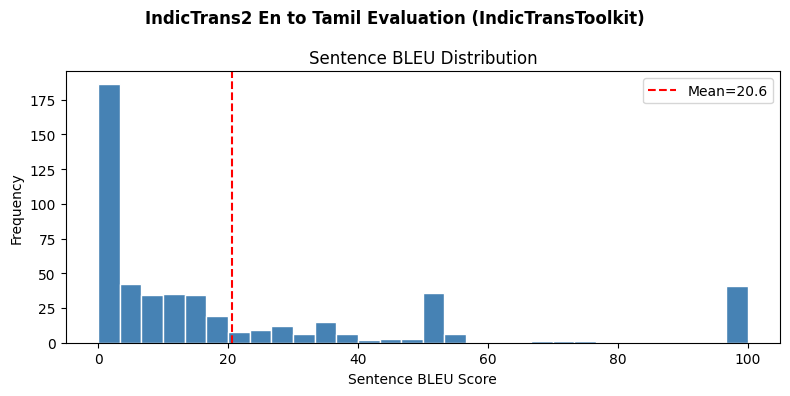

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(8, 4))

mean_bleu = sum(sentence_bleus) / len(sentence_bleus)
ax.hist(df["sentence_bleu"], bins=30, color="steelblue", edgecolor="white")
ax.axvline(mean_bleu, color="red", linestyle="--", label=f"Mean={mean_bleu:.1f}")
ax.set_xlabel("Sentence BLEU Score")
ax.set_ylabel("Frequency")
ax.set_title("Sentence BLEU Distribution")
ax.legend()

plt.suptitle("IndicTrans2 En to Tamil Evaluation (IndicTransToolkit)", fontsize=12, fontweight="bold")
plt.tight_layout()

plot_path = f"{BASE}/data/results/plots/part_a_bleu_analysis.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

# Additional Evaluation Metrics: chrF, chrF++, TER, ROUGE-L

In [13]:
%%capture
!pip install rouge-score


In [15]:
import sacrebleu
import pandas as pd
from rouge_score import rouge_scorer

hypotheses = df["indictrans2_translation"].astype(str).tolist()
references  = df["tamil_reference"].astype(str).tolist()

# Corpus-level
chrf_corpus   = sacrebleu.corpus_chrf(hypotheses, [references])
chrfpp_corpus = sacrebleu.corpus_chrf(hypotheses, [references], word_order=2)
ter_corpus    = sacrebleu.corpus_ter(hypotheses, [references])

# Sentence-level
sentence_chrfs, sentence_chrfpps = [], []
for h, r in zip(hypotheses, references):
    sentence_chrfs.append(round(sacrebleu.sentence_chrf(h, [r]).score, 4))
    sentence_chrfpps.append(round(sacrebleu.sentence_chrf(h, [r], word_order=2).score, 4))

# ROUGE-L
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
sentence_rougeL = []
for h, r in zip(hypotheses, references):
    s = rouge.score(r, h)
    sentence_rougeL.append(round(s['rougeL'].fmeasure * 100, 4))

rouge_corpus = round(sum(sentence_rougeL) / len(sentence_rougeL), 4)

print(f"chrF   (corpus) : {chrf_corpus.score:.4f}")
print(f"chrF++ (corpus) : {chrfpp_corpus.score:.4f}")
print(f"TER    (corpus) : {ter_corpus.score:.4f}  (lower is better)")
print(f"ROUGE-L (avg)   : {rouge_corpus:.4f}")


chrF   (corpus) : 40.4274
chrF++ (corpus) : 35.3432
TER    (corpus) : 88.5305  (lower is better)
ROUGE-L (avg)   : 5.6933


## Save Additional Metrics Results

In [16]:
additional_results = pd.DataFrame([{
    "metric": "chrF",
    "corpus_score": round(chrf_corpus.score, 4),
    "avg_sentence_score": round(sum(sentence_chrfs) / len(sentence_chrfs), 4),
    "max_sentence_score": max(sentence_chrfs),
    "min_sentence_score": min(sentence_chrfs),
}, {
    "metric": "chrF++",
    "corpus_score": round(chrfpp_corpus.score, 4),
    "avg_sentence_score": round(sum(sentence_chrfpps) / len(sentence_chrfpps), 4),
    "max_sentence_score": max(sentence_chrfpps),
    "min_sentence_score": min(sentence_chrfpps),
}, {
    "metric": "TER",
    "corpus_score": round(ter_corpus.score, 4),
    "avg_sentence_score": None,
    "max_sentence_score": None,
    "min_sentence_score": None,
}, {
    "metric": "ROUGE-L",
    "corpus_score": rouge_corpus,
    "avg_sentence_score": rouge_corpus,
    "max_sentence_score": max(sentence_rougeL),
    "min_sentence_score": min(sentence_rougeL),
}])

additional_results.to_csv(
    f"{BASE}/task1_translation_evaluation/part_a_batch_translation/additional_metrics_results.csv",
    index=False
)
additional_results.to_csv(
    f"{BASE}/data/results/additional_metrics_results.csv",
    index=False
)
print(additional_results.to_string(index=False))

# Append per-sentence scores to translation_outputs
df["sentence_chrf"]   = sentence_chrfs
df["sentence_chrfpp"] = sentence_chrfpps
df["sentence_rougeL"] = sentence_rougeL

df.to_csv(
    f"{BASE}/task1_translation_evaluation/part_a_batch_translation/translation_outputs.csv",
    index=False
)
df.to_csv(
    f"{BASE}/data/processed/translated_outputs/translation_outputs.csv",
    index=False
)


 metric  corpus_score  avg_sentence_score  max_sentence_score  min_sentence_score
   chrF       40.4274             40.4735               100.0                 0.0
 chrF++       35.3432             36.6363               100.0                 0.0
    TER       88.5305                 NaN                 NaN                 NaN
ROUGE-L        5.6933              5.6933               100.0                 0.0


## Metric Comparison

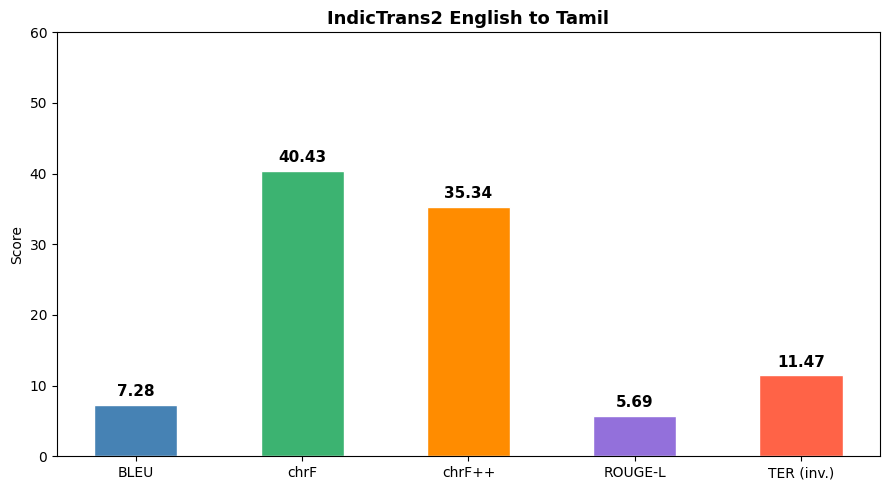

In [17]:
import matplotlib.pyplot as plt

# Normalise TER to 0-100 inverted scale (100 - TER) so higher = better for all
metric_names   = ["BLEU", "chrF", "chrF++", "ROUGE-L", "TER (inv.)"]
metric_scores  = [
    7.28,
    round(chrf_corpus.score, 2),
    round(chrfpp_corpus.score, 2),
    rouge_corpus,
    round(100 - ter_corpus.score, 2),
]
colors = ["steelblue", "mediumseagreen", "darkorange", "mediumpurple", "tomato"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metric_names, metric_scores, color=colors, edgecolor="white", width=0.5)
for bar, score in zip(bars, metric_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{score:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, 60)
ax.set_ylabel("Score")
ax.set_title("IndicTrans2 English to Tamil", fontsize=13, fontweight="bold")
ax.axhline(0, color="grey", linewidth=0.5)
plt.tight_layout()

plot_path = f"{BASE}/data/results/plots/part_a_metric_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

